In [1]:
from model_ranking import (
    adaRandError_eval,
)
from skimage.metrics import (
    adapted_rand_error,  # pyright: ignore[reportUnknownVariableType]
)

INFO: P [MainThread] 2025-09-30 19:57:53,545 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/predictor.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.draw import disk
import random

def generate_instance_segmentation_image(width=256, height=256, num_circles=8, min_radius=15, max_radius=30, seed=None):
    """
    Generate an instance segmentation image with circular objects on black background.
    
    Parameters:
    - width, height: Image dimensions
    - num_circles: Number of circular objects to generate
    - min_radius, max_radius: Range for circle radii
    - seed: Random seed for reproducibility
    
    Returns:
    - Image array where 0 = background, positive integers = instance IDs
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    
    # Initialize black background
    image = np.zeros((height, width), dtype=np.uint16)
    
    circles_placed = []
    instance_id = 1
    
    for _ in range(num_circles):
        attempts = 0
        max_attempts = 100
        
        while attempts < max_attempts:
            # Random center position (avoid edges)
            margin = max_radius + 5
            center_y = random.randint(margin, height - margin)
            center_x = random.randint(margin, width - margin)
            radius = random.randint(min_radius, max_radius)
            
            # Check if circle overlaps with existing ones
            overlap = False
            for prev_y, prev_x, prev_r in circles_placed:
                distance = np.sqrt((center_y - prev_y)**2 + (center_x - prev_x)**2)
                if distance < (radius + prev_r + 5):  # Add small gap between circles
                    overlap = True
                    break
            
            if not overlap:
                # Draw the circle
                rr, cc = disk((center_y, center_x), radius, shape=(height, width))
                image[rr, cc] = instance_id
                circles_placed.append((center_y, center_x, radius))
                instance_id += 1
                break
            
            attempts += 1
    
    return image

# Generate two similar but slightly different images
image1 = generate_instance_segmentation_image(seed=42)
image2 = generate_instance_segmentation_image(seed=43)  # Different seed for variation

print(f"Image 1 - Unique values: {np.unique(image1)}")
print(f"Image 1 - Background pixels: {np.sum(image1 == 0)}/{image1.size} ({100*np.sum(image1 == 0)/image1.size:.1f}%)")
print(f"Image 2 - Unique values: {np.unique(image2)}")
print(f"Image 2 - Background pixels: {np.sum(image2 == 0)}/{image2.size} ({100*np.sum(image2 == 0)/image2.size:.1f}%)")

Image 1 - Unique values: [0 1 2 3 4 5 6 7 8]
Image 1 - Background pixels: 55216/65536 (84.3%)
Image 2 - Unique values: [0 1 2 3 4 5 6 7 8]
Image 2 - Background pixels: 52604/65536 (80.3%)


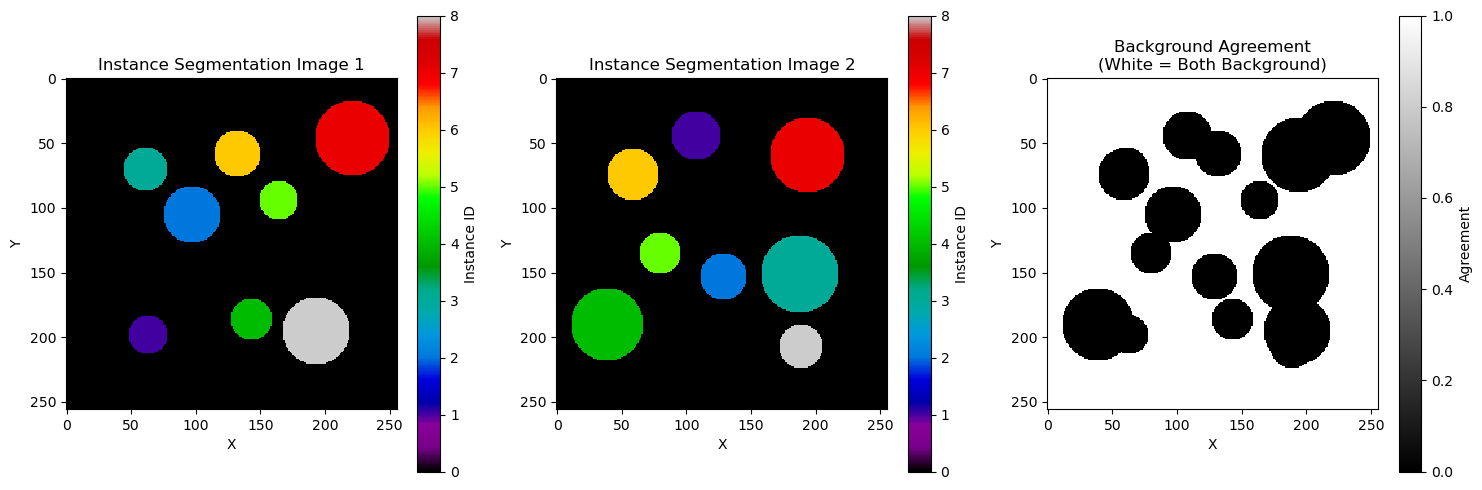


Background Consistency Metrics:
Background IoU: 0.737
Background Dice Coefficient: 0.849
Background pixels in common: 45762
Total background pixels (union): 62058


In [3]:
# Visualize the generated images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Image 1
im1 = axes[0].imshow(image1, cmap='nipy_spectral', interpolation='nearest')
axes[0].set_title('Instance Segmentation Image 1')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
plt.colorbar(im1, ax=axes[0], label='Instance ID')

# Image 2
im2 = axes[1].imshow(image2, cmap='nipy_spectral', interpolation='nearest')
axes[1].set_title('Instance Segmentation Image 2')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
plt.colorbar(im2, ax=axes[1], label='Instance ID')

# Background comparison (black pixels = background agreement)
background_agreement = (image1 == 0) & (image2 == 0)
im3 = axes[2].imshow(background_agreement, cmap='gray', interpolation='nearest')
axes[2].set_title('Background Agreement\n(White = Both Background)')
axes[2].set_xlabel('X')
axes[2].set_ylabel('Y')
plt.colorbar(im3, ax=axes[2], label='Agreement')

plt.tight_layout()
plt.show()

# Calculate background consistency metrics
background_pixels_img1 = (image1 == 0)
background_pixels_img2 = (image2 == 0)
background_overlap = background_pixels_img1 & background_pixels_img2
background_union = background_pixels_img1 | background_pixels_img2

# Intersection over Union (IoU) for background
background_iou = np.sum(background_overlap) / np.sum(background_union)

# Dice coefficient for background
dice_coeff = 2 * np.sum(background_overlap) / (np.sum(background_pixels_img1) + np.sum(background_pixels_img2))

print(f"\nBackground Consistency Metrics:")
print(f"Background IoU: {background_iou:.3f}")
print(f"Background Dice Coefficient: {dice_coeff:.3f}")
print(f"Background pixels in common: {np.sum(background_overlap)}")
print(f"Total background pixels (union): {np.sum(background_union)}")

In [4]:
from model_ranking import get_border_mask

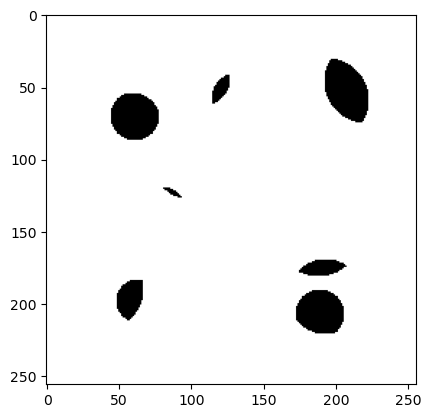

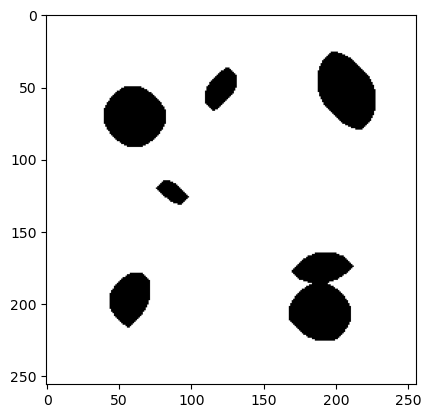

In [5]:
masks = np.zeros((2, *image1.shape))
masks[0] = image1 < 1
masks[1] = image2 < 1
cmb_mask = np.logical_or.reduce(masks, axis=0)
_ = plt.imshow(cmb_mask, cmap='gray')
plt.show()
border_mask = get_border_mask(
    img=cmb_mask.astype(np.uint8), num_dilations=5, num_erosions=5
)
cmb_mask3 = np.logical_and(cmb_mask, ~border_mask)
_ = plt.imshow(cmb_mask3, cmap='gray')
plt.show()

In [6]:
from typing import List, Any
from numpy.typing import NDArray
from model_ranking import avoid_int_overflow

def assign_unique_ids_to_value(data: NDArray[Any], value: List[int] = [0]):
    data = data.copy()
    for v in value:
        max_val = np.max(data)
        max_id_assigned = max_val + np.sum(data == v) + 1
        # check for overflow error
        data = avoid_int_overflow(data, max_id_assigned)
        data[data == v] = np.arange(max_val + 1, max_id_assigned)
    
    return data

In [7]:
img1_masked = image1[cmb_mask]
img2_masked = image2[cmb_mask]
print(img1_masked.shape)
unique1 = np.unique(img1_masked)
unique2 = np.unique(img2_masked)
img1_processed = assign_unique_ids_to_value(img1_masked, list(unique1[1:]))
img2_processed = assign_unique_ids_to_value(img2_masked, list(unique2[1:]))


(62058,)


In [8]:
print(unique1)
print(unique2)

[0 1 2 3 4 5 6 7 8]
[0 1 2 3 4 5 6 7 8]


In [9]:
are, prec, rec = adapted_rand_error(
    img1_masked,
    img2_masked,
    ignore_labels=None,
)
print(1 - are)

0.7254019525097444


In [10]:
are, prec, rec = adapted_rand_error(
    img1_processed,
    img2_processed,
    ignore_labels=None,
)
print(1 - are)

0.7201369379367618


In [11]:
bckg_masked_im1 = np.where(cmb_mask, image1, 0)
bckg_masked_im2 = np.where(cmb_mask, image2, 0)
unique1 = np.unique(bckg_masked_im1)
img1_processed_v2 = assign_unique_ids_to_value(bckg_masked_im1 , list(unique1[1:]))
unique2 = np.unique(bckg_masked_im2)
img2_processed_v2 = assign_unique_ids_to_value(bckg_masked_im2 , list(unique2[1:]))

are, prec, rec = adapted_rand_error(
    img1_processed_v2,
    img2_processed_v2,
    ignore_labels=None,
)
print(are)
are, prec, rec = adapted_rand_error(
    img1_processed_v2.flatten(),
    img2_processed_v2.flatten(),
    ignore_labels=None,
)
print(are)

0.2641864331324282
0.2641864331324282


In [12]:
print(img1_processed_v2.shape)

(256, 256)


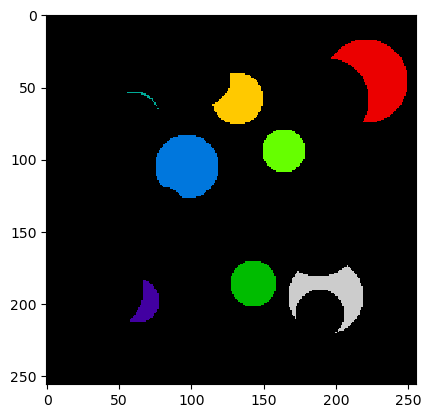

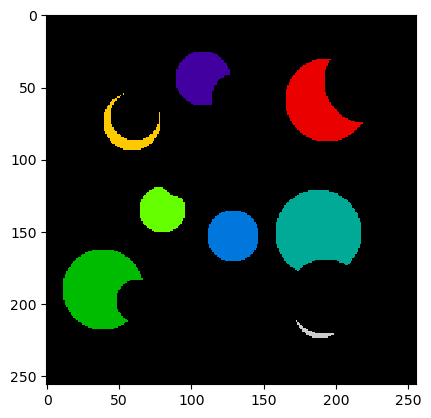

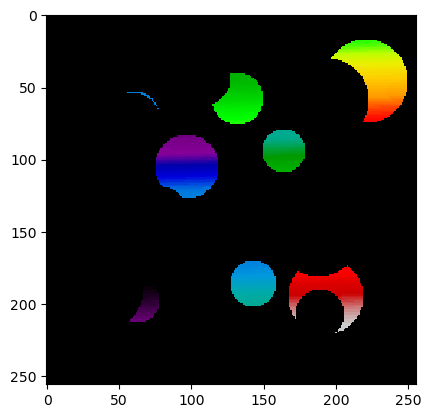

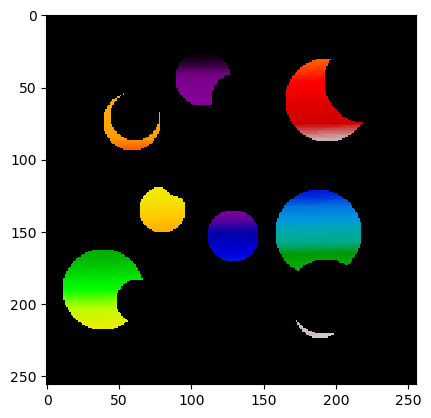

In [13]:
_ = plt.imshow(bckg_masked_im1, cmap='nipy_spectral', interpolation='nearest')
plt.show()
_ = plt.imshow(bckg_masked_im2, cmap='nipy_spectral', interpolation='nearest')
plt.show()
_ = plt.imshow(img1_processed_v2, cmap='nipy_spectral', interpolation='nearest')
plt.show()

_ = plt.imshow(img2_processed_v2, cmap='nipy_spectral', interpolation='nearest')
plt.show()

In [14]:
def move_circle_in_segmentation(image, circle_ids, dx=0, dy=0):
    """
    Move specific circles (instances) in the segmentation image by dx, dy pixels.
    
    Parameters:
    - image: Input segmentation image
    - circle_ids: ID or sequence of IDs of the circles/instances to move
    - dx: horizontal displacement (positive = right)
    - dy: vertical displacement (positive = down)
    
    Returns:
    - Modified image with the circles moved
    """
    # Create a copy of the image
    modified_image = image.copy()
    
    # Ensure circle_ids is iterable (convert single ID to list)
    if isinstance(circle_ids, (int, np.integer)):
        circle_ids = [circle_ids]
    
    # Process each circle ID
    for circle_id in circle_ids:
        # Find pixels belonging to the specified circle
        circle_mask = (image == circle_id)
        
        if not np.any(circle_mask):
            print(f"Circle with ID {circle_id} not found in the image")
            continue
        
        # Remove the original circle
        modified_image[circle_mask] = 0
        
        # Get coordinates of the circle pixels
        y_coords, x_coords = np.where(circle_mask)
        
        # Calculate new positions
        new_y_coords = y_coords + dy
        new_x_coords = x_coords + dx
        
        # Check bounds and filter valid coordinates
        height, width = image.shape
        valid_mask = (
            (new_y_coords >= 0) & (new_y_coords < height) &
            (new_x_coords >= 0) & (new_x_coords < width)
        )
        
        valid_new_y = new_y_coords[valid_mask]
        valid_new_x = new_x_coords[valid_mask]
        
        # Check for collisions with existing instances (excluding background)
        collision_mask = modified_image[valid_new_y, valid_new_x] > 0
        
        # Only place pixels where there's no collision
        no_collision_y = valid_new_y[~collision_mask]
        no_collision_x = valid_new_x[~collision_mask]
        
        # Place the circle in its new position
        modified_image[no_collision_y, no_collision_x] = circle_id
    
    return modified_image

# Let's see what circles are available in image1
available_circles = np.unique(image1)
print(f"Available circles in image1: {available_circles}")
print(f"Background (0) and {len(available_circles)-1} circles")

# Move the first non-background circle (ID 1) by 10 pixels to the right
if len(available_circles) > 1:
    circles_to_move = available_circles[1:3]  # First non-background circle
    image1_modified = move_circle_in_segmentation(image1, circles_to_move, dx=10, dy=0)
    
    print(f"Moved circle {circles_to_move} by 10 pixels to the right")
else:
    print("No circles found to move")
    image1_modified = image1.copy()

Available circles in image1: [0 1 2 3 4 5 6 7 8]
Background (0) and 8 circles
Moved circle [1 2] by 10 pixels to the right


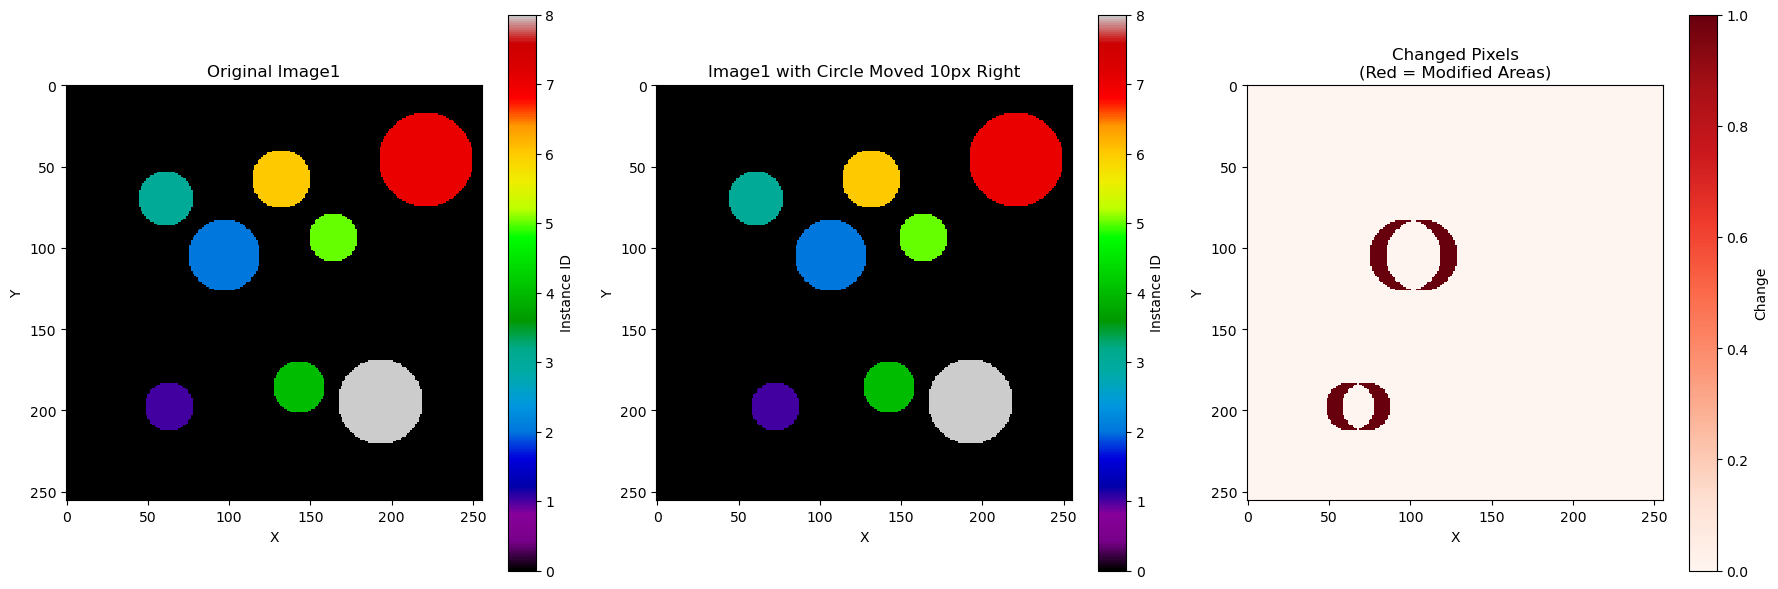


Modification Statistics:
Total pixels changed: 1440
Percentage of image modified: 2.20%
Circle 1 pixels in original: 697
Circle 1 pixels in modified: 697
✓ Circle size preserved during move


In [15]:
# Visualize the original and modified images
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original image1
im1 = axes[0].imshow(image1, cmap='nipy_spectral', interpolation='nearest')
axes[0].set_title('Original Image1')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
plt.colorbar(im1, ax=axes[0], label='Instance ID')

# Modified image1 (with moved circle)
im2 = axes[1].imshow(image1_modified, cmap='nipy_spectral', interpolation='nearest')
axes[1].set_title('Image1 with Circle Moved 10px Right')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
plt.colorbar(im2, ax=axes[1], label='Instance ID')

# Difference visualization (highlighting the change)
difference = (image1 != image1_modified).astype(int)
im3 = axes[2].imshow(difference, cmap='Reds', interpolation='nearest')
axes[2].set_title('Changed Pixels\n(Red = Modified Areas)')
axes[2].set_xlabel('X')
axes[2].set_ylabel('Y')
plt.colorbar(im3, ax=axes[2], label='Change')

plt.tight_layout()
plt.show()

# Print some statistics about the change
changed_pixels = np.sum(difference)
total_pixels = image1.size
print(f"\nModification Statistics:")
print(f"Total pixels changed: {changed_pixels}")
print(f"Percentage of image modified: {100*changed_pixels/total_pixels:.2f}%")

# Verify the circle was moved correctly
circle_id = available_circles[1] if len(available_circles) > 1 else 0
original_circle_pixels = np.sum(image1 == circle_id)
modified_circle_pixels = np.sum(image1_modified == circle_id)
print(f"Circle {circle_id} pixels in original: {original_circle_pixels}")
print(f"Circle {circle_id} pixels in modified: {modified_circle_pixels}")

if original_circle_pixels == modified_circle_pixels:
    print("✓ Circle size preserved during move")
else:
    print("⚠ Circle size changed during move (possible collision or boundary issues)")

In [16]:
circles_to_move = available_circles[1]  # First non-background circle
image1_modified = move_circle_in_segmentation(image1, circles_to_move, dx=10, dy=0)
image1_modified_v2 = move_circle_in_segmentation(image1, available_circles[1:5], dx=10, dy=0)
image1_modified_v3 = move_circle_in_segmentation(image1, available_circles[1:], dx=10, dy=0)

In [17]:
masks = np.zeros((2, *image1.shape))
masks[0] = image1 < 1
masks[1] = image1_modified < 1
cmb_mask = np.logical_or.reduce(masks, axis=0)
# _ = plt.imshow(cmb_mask, cmap='gray')
# plt.show()

img1_masked = image1[cmb_mask]
img1_modified_masked = image1_modified[cmb_mask]
unique1 = np.unique(img1_masked)
unique2 = np.unique(img1_modified_masked)
img1_processed = assign_unique_ids_to_value(img1_masked, list(unique1[1:]))
img2_processed = assign_unique_ids_to_value(img1_modified_masked, list(unique2[1:]))
are, prec, rec = adapted_rand_error(
    img1_processed,
    img2_processed,
    ignore_labels=None,
)
print(1 - are)

0.9895232882612431


In [18]:
masks = np.zeros((2, *image1.shape))
masks[0] = image1 < 1
masks[1] = image1_modified_v2 < 1
cmb_mask = np.logical_or.reduce(masks, axis=0)
# _ = plt.imshow(cmb_mask, cmap='gray')
# plt.show()

img1_masked = image1[cmb_mask]
img1_modified_masked = image1_modified_v2[cmb_mask]
unique1 = np.unique(img1_masked)
unique2 = np.unique(img1_modified_masked)
img1_processed = assign_unique_ids_to_value(img1_masked, list(unique1[1:]))
img2_processed = assign_unique_ids_to_value(img1_modified_masked, list(unique2[1:]))
are, prec, rec = adapted_rand_error(
    img1_processed,
    img2_processed,
    ignore_labels=None,
)
print(1 - are)

0.9514175417355627


In [19]:
from model_ranking import (
    get_mask
)

In [20]:
-0 > -0.1

True

In [21]:
np.unique(-image1.astype(np.int16))

array([-8, -7, -6, -5, -4, -3, -2, -1,  0], dtype=int16)

In [22]:
cmb_mask2 = get_mask(-image1.astype(np.int16), -image1_modified_v3.astype(np.int16), -1)

In [23]:
masks = np.zeros((2, *image1.shape))
masks[0] = image1 < 1
masks[1] = image1_modified_v3 < 1
cmb_mask = np.logical_or.reduce(masks, axis=0)

In [24]:
np.all(np.equal(cmb_mask, cmb_mask2))

True

In [25]:
masks = np.zeros((2, *image1.shape))
masks[0] = image1 < 1
masks[1] = image1_modified_v3 < 1
cmb_mask = np.logical_or.reduce(masks, axis=0)
# _ = plt.imshow(cmb_mask, cmap='gray')
# plt.show()

img1_masked = image1[cmb_mask]
img1_modified_masked = image1_modified_v3[cmb_mask]
unique1 = np.unique(img1_masked)
unique2 = np.unique(img1_modified_masked)
img1_processed = assign_unique_ids_to_value(img1_masked, list(unique1[1:]))
img2_processed = assign_unique_ids_to_value(img1_modified_masked, list(unique2[1:]))
are, prec, rec = adapted_rand_error(
    img1_processed,
    img2_processed,
    ignore_labels=None,
)
print(1 - are)

0.8932445325742101


In [27]:
batch_scores, mask = adaRandError_eval(
    image1_modified_v3,
    image1,
    incomplete_gt=False,
    num_dilations=None,
    num_erosions=None,
    bckg=True
)

In [28]:
1 - batch_scores

array([[0.8932445 , 0.10523349, 0.10827225]], dtype=float32)